In [45]:
import fast_rv as frv
import numpy as np
import matplotlib.cm
import matplotlib.pyplot as plt
cmap = matplotlib.cm.get_cmap("Spectral")
#%matplotlib widget
#matplotlib.use("TkAgg")
from matplotlib.widgets import RangeSlider
from PyAstronomy.modelSuite import KeplerRVModel
from astroquery.vizier import Vizier
from astropy.timeseries import LombScargle

/tmp/ipykernel_5677/3176628646.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Spectral")


In [46]:
catalog_id = "J/A+A/664/A53"
t = frv.vizier_table_inspection(catalog_id)


Table description: RV and bissector span taken with CORALIE spectrograph
Total data points: 45
Time : Barycentric Julian Date of observation (BJD-2400000)
RV   : Radial velocity
Err  : Radial velocity uncertainty
authors:                                 authors                                
-----------------------------------------------------------------------
Stalport M.; Delisle J.-B.; Udry S.; Matthews E.; Bourrier V.; Leleu A.


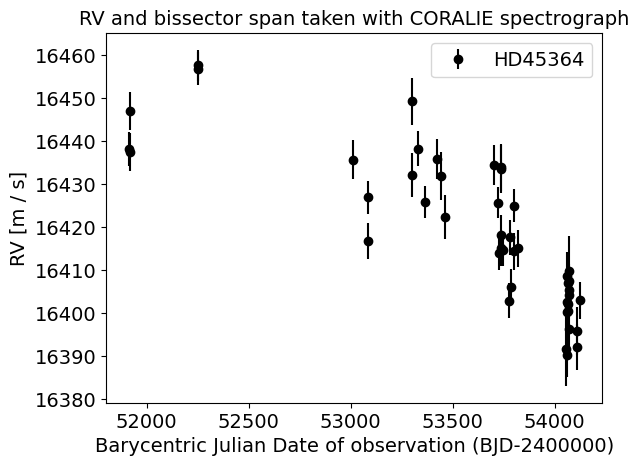

In [47]:
name = "HD45364" 
time_data, rv_data_ms , err_rv_ms = frv.get_vizier_data(catalog_id,name)
plt.show()
                        

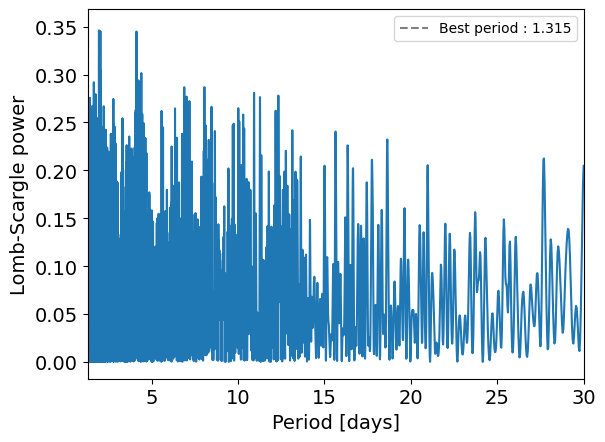

np.float64(1.315231772643409)

In [48]:
#in this case a periodogram fails
#if we change the limit, the maximum value changes too !
#thos current issue needs to be resolved in the next version !
#cross check your period guess always with the archive data ! 
period_guess = frv.run_periodogram( time_data , rv_data_ms , err_rv_ms , 1.3, 30)
plt.show()
period_guess


In [49]:
#from NASA exop;anet archive 
params = {
    "mstar": 0.82,
    "per": 225.79,
    "e": 0.067,
    "w": 92,
    "K": 7.23
}
x_data, y_data, y_err, xgrid, ygrid, model = frv.fitting_rv_model(time_data, rv_data_ms, 
                                                              err_rv_ms, **params)
                        

Optimization terminated successfully.
         Current function value: 604.546512
         Iterations: 114
         Function evaluations: 217


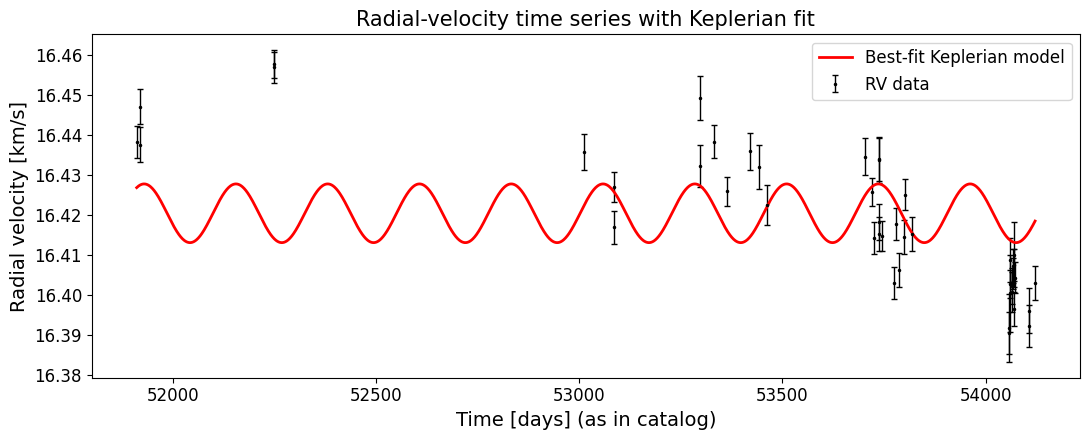

In [50]:
plt.figure(figsize=(11, 4.5))

# data
plt.errorbar(
    x_data, y_data/1e3, yerr=y_err/1e3,
    fmt="k.", ms=3, capsize=2, elinewidth=1,
    label="RV data"
)
# model
plt.plot(xgrid, ygrid/1e3, "r-", lw=2, label="Best-fit Keplerian model")

plt.title("Radial-velocity time series with Keplerian fit", fontsize=15)
plt.xlabel("Time [days] (as in catalog)", fontsize=14)
plt.ylabel("Radial velocity [km/s]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

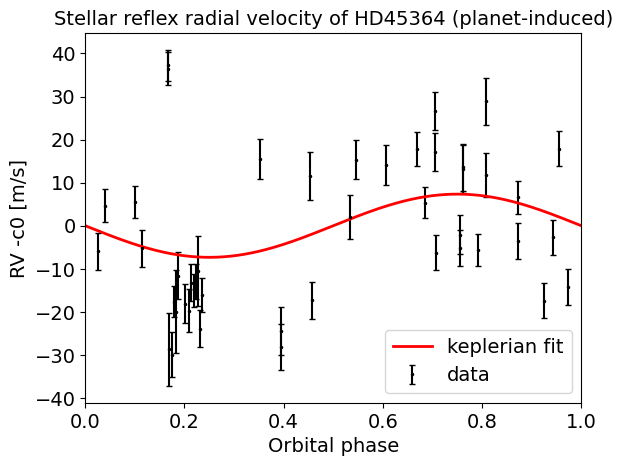

In [51]:
#finally - phase fold it
phase = ((x_data - model["tau1"]) / model["per1"]) % 1.0
idx_p = np.argsort(phase)

phase_grid = np.linspace(0, 1, 2000)
x_phase = model["tau1"] + phase_grid * model["per1"]
y_phase = model.evaluate(x_phase)


plt.errorbar(phase[idx_p], (y_data - model["c0"])[idx_p], yerr=y_err[idx_p],
             fmt="k.", ms=3, capsize=2, label="data")
plt.plot(phase_grid, y_phase - model["c0"], "r-", lw=2, label="keplerian fit")
plt.xlim(0, 1)
plt.xlabel("Orbital phase", fontsize = 14)
plt.ylabel("RV -c0 [m/s]" , fontsize = 14)
plt.title(f"Stellar reflex radial velocity of {name} (planet-induced)",fontsize = 14)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14)
plt.legend( fontsize = 14)
plt.show()